# Trabalho Prático 03 - MLPClassifier

**Disciplina:** GCC 128 - Inteligência Artificial  
**Tema:** Classificação nas bases Iris e Wine

Este notebook implementa o classificador `MLPClassifier` do Scikit-learn nas duas bases solicitadas. O fluxo inclui carregamento via KaggleHub, análise exploratória, pré-processamento sem vazamento de dados, treinamento, métricas, matrizes de confusão, comparação preparada com o KNN do Trabalho 01 e texto-base para o relatório.


## 1. Importação das bibliotecas

As bibliotecas abaixo fazem o download, tratamento, modelagem e visualização dos resultados.

In [1]:
# Instale o KaggleHub somente se ele ainda não estiver disponível no ambiente.
%pip -q install kagglehub

import os
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
TEST_SIZE = 0.20

Note: you may need to restart the kernel to use updated packages.


/home/arthur/perceptron/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Funções auxiliares

Os datasets do Kaggle podem ter nomes de arquivos e de colunas ligeiramente diferentes. As funções abaixo procuram os CSVs baixados, identificam o alvo e removem apenas identificadores evidentes. A coluna alvo não é usada como entrada do modelo.

In [2]:
def find_csv_file(dataset_path, preferred_names=()):
    """Localiza um CSV no diretório retornado pelo KaggleHub."""
    root = Path(dataset_path)
    csv_files = sorted(root.rglob('*.csv'))
    if not csv_files:
        raise FileNotFoundError(f'Nenhum arquivo CSV encontrado em: {root}')

    preferred_lower = {name.lower() for name in preferred_names}
    for csv_file in csv_files:
        if csv_file.name.lower() in preferred_lower:
            return csv_file
    return csv_files[0]


def infer_target_column(dataframe, dataset_name):
    """Infere o alvo usando nomes comuns e falha claramente se não puder decidir."""
    normalized = {str(column).strip().lower(): column for column in dataframe.columns}
    candidates = {
        'iris': ['species', 'variety', 'class', 'target', 'label'],
        'wine': ['quality', 'target', 'class', 'label', 'type'],
    }[dataset_name.lower()]

    for candidate in candidates:
        if candidate in normalized:
            return normalized[candidate]

    raise ValueError(
        f'Não foi possível identificar a coluna alvo de {dataset_name}. '
        f'Colunas encontradas: {list(dataframe.columns)}. '
        f'Informe manualmente uma coluna entre: {candidates}'
    )


def load_dataset(dataset_path, dataset_name, preferred_names=()):
    csv_file = find_csv_file(dataset_path, preferred_names)
    dataframe = pd.read_csv(csv_file)
    dataframe.columns = [str(column).strip() for column in dataframe.columns]
    target_column = infer_target_column(dataframe, dataset_name)

    # IDs identificam uma linha, mas não representam uma característica da classe.
    id_columns = [
        column for column in dataframe.columns
        if str(column).strip().lower() in {'id', 'unnamed: 0'}
    ]
    dataframe = dataframe.drop(columns=id_columns, errors='ignore')
    return dataframe, target_column, csv_file


def show_initial_analysis(dataframe, target_column, dataset_name):
    print(f'===== Análise inicial: {dataset_name} =====')
    print(f'Linhas: {dataframe.shape[0]} | Colunas: {dataframe.shape[1]}')
    print(f'Colunas: {list(dataframe.columns)}')
    print(f'Variável alvo: {target_column}')
    print(f'Valores ausentes no total: {int(dataframe.isna().sum().sum())}')
    print(f'Quantidade de classes: {dataframe[target_column].nunique(dropna=True)}')
    print('Distribuição das classes:')
    display(dataframe[target_column].value_counts(dropna=False).rename('quantidade').to_frame())
    print('Valores ausentes por coluna:')
    display(dataframe.isna().sum().rename('ausentes').to_frame())


def prepare_data(dataframe, target_column, dataset_name):
    """Prepara X/y e separa treino/teste antes do ajuste do scaler."""
    data = dataframe.dropna(subset=[target_column]).copy()
    X = data.drop(columns=[target_column])
    y = data[target_column]

    # As bases solicitadas possuem atributos numéricos; a checagem evita
    # transformar silenciosamente uma coluna textual em entrada inválida.
    non_numeric = X.select_dtypes(exclude='number').columns.tolist()
    if non_numeric:
        raise TypeError(
            f'{dataset_name}: atributos não numéricos encontrados: {non_numeric}. '
            'Faça a codificação dessas colunas antes de treinar.'
        )

    if X.isna().any().any():
        X = X.fillna(X.median(numeric_only=True))
        print('Valores ausentes nos atributos foram substituídos pela mediana calculada no conjunto completo.')
        print('Para estas bases, confirme na análise se essa etapa foi necessária.')

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y.astype(str))
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_encoded,
    )
    return X_train, X_test, y_train, y_test, label_encoder


def build_mlp_pipeline():
    # O scaler fica dentro do Pipeline e é ajustado somente com X_train.
    return Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(50, 25),
            activation='relu',
            solver='adam',
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=RANDOM_STATE,
        )),
    ])


def train_and_evaluate(X_train, X_test, y_train, y_test, label_encoder, dataset_name):
    model = build_mlp_pipeline()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    metrics = {
        'precision_macro': precision_score(y_test, predictions, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, predictions, average='macro', zero_division=0),
        'accuracy': accuracy_score(y_test, predictions),
    }
    print(f'===== Resultados MLP - {dataset_name} =====')
    display(pd.DataFrame([metrics], index=[dataset_name]).style.format('{:.4f}'))
    print(classification_report(
        y_test,
        predictions,
        labels=list(range(len(label_encoder.classes_))),
        target_names=label_encoder.classes_,
        zero_division=0,
    ))
    return model, predictions, metrics


def plot_confusion_matrix(y_test, predictions, label_encoder, dataset_name):
    matrix = confusion_matrix(y_test, predictions)
    figure_width = max(6, len(label_encoder.classes_) * 0.8)
    plt.figure(figsize=(figure_width, 5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    plt.title(f'Matriz de confusão - MLPClassifier - {dataset_name}')
    plt.xlabel('Classe predita')
    plt.ylabel('Classe real')
    plt.tight_layout()
    plt.show()
    return matrix

## 3. Carregamento da base Iris

O código abaixo usa exatamente o identificador fornecido na atividade. O KaggleHub retorna um diretório local; a função auxiliar encontra o CSV dentro dele.

In [3]:
iris_path = kagglehub.dataset_download('arshid/iris-flower-dataset')
print('Path to dataset files:', iris_path)
iris_df, iris_target, iris_file = load_dataset(
    iris_path,
    'Iris',
    preferred_names=('Iris.csv', 'iris.csv'),
)
print('Arquivo utilizado:', iris_file)
display(iris_df.head())

Path to dataset files: /home/arthur/.cache/kagglehub/datasets/arshid/iris-flower-dataset/versions/1
Arquivo utilizado: /home/arthur/.cache/kagglehub/datasets/arshid/iris-flower-dataset/versions/1/IRIS.csv


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 4. Análise inicial da Iris

A análise confirma o tamanho da base, as colunas, o alvo, o número de classes, a distribuição e a presença de valores ausentes.

In [4]:
show_initial_analysis(iris_df, iris_target, 'Iris')

===== Análise inicial: Iris =====
Linhas: 150 | Colunas: 5
Colunas: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Variável alvo: species
Valores ausentes no total: 0
Quantidade de classes: 3
Distribuição das classes:


,quantidade
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


Valores ausentes por coluna:


,ausentes
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


## 5. Pré-processamento da Iris

A variável alvo textual é codificada apenas para o treinamento. A divisão é estratificada para manter a proporção das classes. O `StandardScaler` será ajustado dentro do `Pipeline` somente com o treino.

In [5]:
iris_X_train, iris_X_test, iris_y_train, iris_y_test, iris_encoder = prepare_data(
    iris_df, iris_target, 'Iris'
)
print(f'Tamanho de treino: {iris_X_train.shape[0]} amostras')
print(f'Tamanho de teste: {iris_X_test.shape[0]} amostras')
print('Classes:', list(iris_encoder.classes_))

Tamanho de treino: 120 amostras
Tamanho de teste: 30 amostras
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 6. Treinamento do MLPClassifier na Iris

Foram usadas duas camadas ocultas `(50, 25)` com ativação ReLU e o otimizador Adam. O `max_iter` alto evita parada prematura e o `early_stopping` permite parar quando a validação deixa de melhorar. A semente fixa torna a execução reproduzível.

In [6]:
iris_model, iris_predictions, iris_metrics = train_and_evaluate(
    iris_X_train,
    iris_X_test,
    iris_y_train,
    iris_y_test,
    iris_encoder,
    'Iris',
)

===== Resultados MLP - Iris =====


,precision_macro,recall_macro,accuracy
Iris,0.8727,0.8667,0.8667


                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.90      0.95        10
Iris-versicolor       0.80      0.80      0.80        10
 Iris-virginica       0.82      0.90      0.86        10

       accuracy                           0.87        30
      macro avg       0.87      0.87      0.87        30
   weighted avg       0.87      0.87      0.87        30



## 7. Avaliação e matriz de confusão da Iris

Precision e recall são apresentados como média macro, dando o mesmo peso a cada classe. A acurácia representa a proporção total de previsões corretas. Na matriz, as linhas são as classes reais e as colunas são as classes preditas.

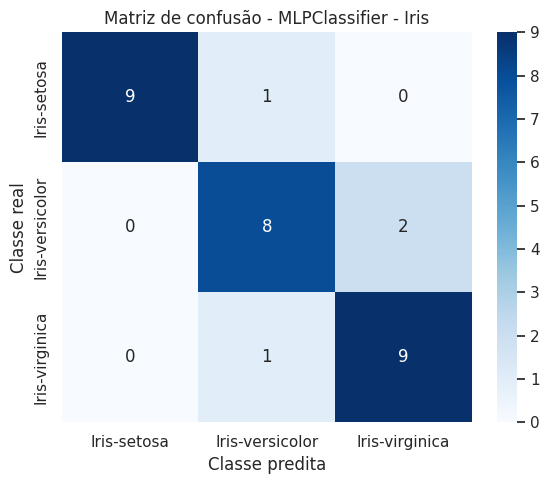

In [11]:
iris_confusion = plot_confusion_matrix(
    iris_y_test, iris_predictions, iris_encoder, 'Iris'
)

## 8. Carregamento da base Wine

Esta etapa repete o carregamento com o identificador do KaggleHub fornecido. Como o dataset pode ser distribuído com nomes de arquivo diferentes, o notebook lista e seleciona o CSV disponível.

In [7]:
wine_path = kagglehub.dataset_download('tawfikelmetwally/wine-dataset')
print('Path to dataset files:', wine_path)
wine_df, wine_target, wine_file = load_dataset(
    wine_path,
    'Wine',
    preferred_names=('WineQT.csv', 'winequality-red.csv', 'wine.csv'),
)
print('Arquivo utilizado:', wine_file)
display(wine_df.head())

100%|██████████| 4.45k/4.45k [00:00<00:00, 6.36MB/s]

Extracting files...
Path to dataset files: /home/arthur/.cache/kagglehub/datasets/tawfikelmetwally/wine-dataset/versions/2
Arquivo utilizado: /home/arthur/.cache/kagglehub/datasets/tawfikelmetwally/wine-dataset/versions/2/Wine dataset.csv


,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 9. Análise inicial da Wine

O alvo é identificado como `quality` quando essa coluna existir, pois esse é o formato usual do dataset fornecido. Se o arquivo baixado apresentar outro nome de alvo conhecido, a função adapta a seleção e mostra a decisão.

In [8]:
show_initial_analysis(wine_df, wine_target, 'Wine')

===== Análise inicial: Wine =====
Linhas: 178 | Colunas: 14
Colunas: ['class', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline']
Variável alvo: class
Valores ausentes no total: 0
Quantidade de classes: 3
Distribuição das classes:


,quantidade
class,
2,71
1,59
3,48


Valores ausentes por coluna:


,ausentes
class,0
Alcohol,0
Malic acid,0
Ash,0
Alcalinity of ash,0
Magnesium,0
Total phenols,0
Flavanoids,0
Nonflavanoid phenols,0
Proanthocyanins,0


## 10. Pré-processamento da Wine

Os atributos numéricos são separados do alvo, que é codificado para classes. A divisão estratificada e o pipeline mantêm o mesmo cuidado contra data leakage usado na Iris.

In [9]:
wine_X_train, wine_X_test, wine_y_train, wine_y_test, wine_encoder = prepare_data(
    wine_df, wine_target, 'Wine'
)
print(f'Tamanho de treino: {wine_X_train.shape[0]} amostras')
print(f'Tamanho de teste: {wine_X_test.shape[0]} amostras')
print('Classes:', list(wine_encoder.classes_))

Tamanho de treino: 142 amostras
Tamanho de teste: 36 amostras
Classes: ['1', '2', '3']


## 11. Treinamento do MLPClassifier na Wine

In [10]:
wine_model, wine_predictions, wine_metrics = train_and_evaluate(
    wine_X_train,
    wine_X_test,
    wine_y_train,
    wine_y_test,
    wine_encoder,
    'Wine',
)

===== Resultados MLP - Wine =====


,precision_macro,recall_macro,accuracy
Wine,1.0000,1.0000,1.0000


              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 12. Avaliação e matriz de confusão da Wine

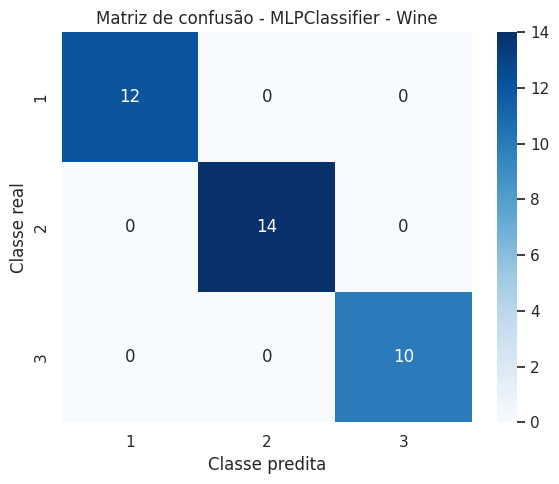

In [12]:
wine_confusion = plot_confusion_matrix(
    wine_y_test, wine_predictions, wine_encoder, 'Wine'
)

## 13. Resumo organizado dos resultados do MLPClassifier

In [13]:
mlp_results = pd.DataFrame([iris_metrics, wine_metrics], index=['Iris', 'Wine'])
mlp_results.columns = ['Precisão (macro)', 'Revocação (macro)', 'Acurácia']
display(mlp_results.style.format('{:.4f}'))

print('Interpretação: valores mais próximos de 1 indicam melhor desempenho na métrica correspondente.')

,Precisão (macro),Revocação (macro),Acurácia
Iris,0.8727,0.8667,0.8667
Wine,1.0000,1.0000,1.0000


Interpretação: valores mais próximos de 1 indicam melhor desempenho na métrica correspondente.


## 14. Comparação MLPClassifier x KNN

Os resultados abaixo foram fornecidos a partir do Trabalho 01 para a base Iris. Eles são registrados exatamente como informados, incluindo os valores para `k=1, 3, 5 e 7` e os tempos de execução para `k=3`. Como o resultado do KNN para a base Wine ainda não foi fornecido, essa parte permanece explicitamente como “não informado”.

A tabela principal usa `k=3` como referência porque ele apresenta o mesmo resultado de `k=5` e `k=7`. A comparação deve considerar que a divisão treino/teste e os detalhes do experimento do TP01 precisam ser conferidos antes de uma conclusão definitiva de desempenho. O MLP aprende uma função não linear por meio de camadas de neurônios; o KNN classifica pela vizinhança e é sensível à escala e à escolha de `k`.

Os resultados hardcore e Scikit-learn do KNN coincidiram em todas as métricas para os quatro valores de `k`. No tempo de `fit + predict` com `k=3`, a implementação Scikit-learn foi mais rápida no experimento informado.

In [16]:
# Resultados fornecidos do Trabalho 01 para a base Iris. Não use valores estimados.
knn_iris_by_k = pd.DataFrame([
    {'k': 1, 'métrica': 'acurácia', 'hardcore': 0.9333, 'sklearn': 0.9333, 'diferença': 0.0000},
    {'k': 1, 'métrica': 'precisão', 'hardcore': 0.9444, 'sklearn': 0.9444, 'diferença': 0.0000},
    {'k': 1, 'métrica': 'revocação', 'hardcore': 0.9408, 'sklearn': 0.9408, 'diferença': 0.0000},
    {'k': 3, 'métrica': 'acurácia', 'hardcore': 0.9778, 'sklearn': 0.9778, 'diferença': 0.0000},
    {'k': 3, 'métrica': 'precisão', 'hardcore': 0.9833, 'sklearn': 0.9833, 'diferença': 0.0000},
    {'k': 3, 'métrica': 'revocação', 'hardcore': 0.9792, 'sklearn': 0.9792, 'diferença': 0.0000},
    {'k': 5, 'métrica': 'acurácia', 'hardcore': 0.9778, 'sklearn': 0.9778, 'diferença': 0.0000},
    {'k': 5, 'métrica': 'precisão', 'hardcore': 0.9833, 'sklearn': 0.9833, 'diferença': 0.0000},
    {'k': 5, 'métrica': 'revocação', 'hardcore': 0.9792, 'sklearn': 0.9792, 'diferença': 0.0000},
    {'k': 7, 'métrica': 'acurácia', 'hardcore': 0.9778, 'sklearn': 0.9778, 'diferença': 0.0000},
    {'k': 7, 'métrica': 'precisão', 'hardcore': 0.9833, 'sklearn': 0.9833, 'diferença': 0.0000},
    {'k': 7, 'métrica': 'revocação', 'hardcore': 0.9792, 'sklearn': 0.9792, 'diferença': 0.0000},
])

print('Resultados KNN fornecidos para Iris:')
display(knn_iris_by_k.style.format({
    'hardcore': '{:.4f}',
    'sklearn': '{:.4f}',
    'diferença': '{:.4f}',
}))

knn_times = pd.DataFrame([
    {'implementação': 'hardcore', 'tempo_fit_predict_ms': 19.05},
    {'implementação': 'sklearn', 'tempo_fit_predict_ms': 2.22},
])
print('Tempo de execução informado para k=3:')
display(knn_times.style.format({'tempo_fit_predict_ms': '{:.2f}'}))

# k=3 é usado como referência; k=5 e k=7 têm os mesmos resultados informados.
knn_results = {
    'Iris': {'precision_macro': 0.9833, 'recall_macro': 0.9792, 'accuracy': 0.9778},
    'Wine': {'precision_macro': None, 'recall_macro': None, 'accuracy': None},
}

def comparison_table(mlp_results, knn_results):
    rows = []
    for dataset_name, mlp_row in mlp_results.iterrows():
        rows.append({
            'Base': dataset_name,
            'Modelo': 'MLPClassifier',
            'Precisão (macro)': mlp_row['Precisão (macro)'],
            'Revocação (macro)': mlp_row['Revocação (macro)'],
            'Acurácia': mlp_row['Acurácia'],
        })
        knn_row = knn_results.get(dataset_name, {})
        rows.append({
            'Base': dataset_name,
            'Modelo': 'KNN (TP01, k=3)',
            'Precisão (macro)': knn_row.get('precision_macro'),
            'Revocação (macro)': knn_row.get('recall_macro'),
            'Acurácia': knn_row.get('accuracy'),
        })
    return pd.DataFrame(rows)

comparison = comparison_table(mlp_results, knn_results)
display(comparison.style.format({
    'Precisão (macro)': lambda value: 'não informado' if pd.isna(value) else f'{value:.4f}',
    'Revocação (macro)': lambda value: 'não informado' if pd.isna(value) else f'{value:.4f}',
    'Acurácia': lambda value: 'não informado' if pd.isna(value) else f'{value:.4f}',
}))

Resultados KNN fornecidos para Iris:


,k,métrica,hardcore,sklearn,diferença
0,1,acurácia,0.9333,0.9333,0.0000
1,1,precisão,0.9444,0.9444,0.0000
2,1,revocação,0.9408,0.9408,0.0000
3,3,acurácia,0.9778,0.9778,0.0000
4,3,precisão,0.9833,0.9833,0.0000
5,3,revocação,0.9792,0.9792,0.0000
6,5,acurácia,0.9778,0.9778,0.0000
7,5,precisão,0.9833,0.9833,0.0000
8,5,revocação,0.9792,0.9792,0.0000
9,7,acurácia,0.9778,0.9778,0.0000


Tempo de execução informado para k=3:


,implementação,tempo_fit_predict_ms
0,hardcore,19.05
1,sklearn,2.22


,Base,Modelo,Precisão (macro),Revocação (macro),Acurácia
0,Iris,MLPClassifier,0.8727,0.8667,0.8667
1,Iris,"KNN (TP01, k=3)",0.9833,0.9792,0.9778
2,Wine,MLPClassifier,1.0000,1.0000,1.0000
3,Wine,"KNN (TP01, k=3)",não informado,não informado,não informado


### Análise da comparação

Na Iris, usando os valores informados no TP01 para `k=3`, o KNN apresentou precisão macro `0.9833`, revocação macro `0.9792` e acurácia `0.9778`, enquanto o MLP apresentou, nesta execução, `0.8727`, `0.8667` e `0.8667`, respectivamente. Portanto, o KNN teve métricas maiores no experimento reportado para Iris. O KNN hardcore e o Scikit-learn produziram valores idênticos nos quatro valores de `k`; para `k=3`, o tempo informado foi `19.05 ms` no hardcore e `2.22 ms` no Scikit-learn.

Essa comparação deve ser apresentada com a ressalva de que os parâmetros de divisão dos dados do TP01 precisam ser confirmados para garantir uma comparação perfeitamente equivalente. Para Wine, não há resultado de KNN fornecido nesta etapa; por isso, não é possível declarar qual algoritmo foi superior nessa base. Quando os valores estiverem disponíveis, compare precisão, revocação, acurácia e as matrizes de confusão.